In [1]:
import ee
import json
import math
import os
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from tqdm import tqdm
from umap import UMAP
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

# ---- USER INPUTS ----
# Run gen_rand_coords.ipynb first to generate N random coordinates
N = 400  # number of random points to sample
EMBED_PIXELS = 64  # patch width (px)
EMBED_SCALE = 10  # m/px (AlphaEarth native)
YEAR = 2024
SEED = 42

OUTPUT_DIR = f"output/{N}_{EMBED_PIXELS}_{EMBED_SCALE}_{YEAR}"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [ ]:
# Get AlphaEarth embeddings for random points with Earth Engine, arrange into 2D grid via UMAP

print("Initializing Google Earth Engine...")
ee.Authenticate()
ee.Initialize(project="gsapp-map")
print("✔ Earth Engine initialized\n")

# ---- LOAD INPUT COORDS ----
INPUT_COORDS = f"us-samples/random_coords_{N}.json"  # list of dicts with lat/lon
print(f"Loading coordinates from {INPUT_COORDS} ...")
with open(INPUT_COORDS, "r") as f:
    coords_list = json.load(f)

gdf = pd.DataFrame(coords_list)
if not {"lat", "lon"}.issubset(gdf.columns):
    gdf.columns = ["lon", "lat"]

print(f"Loaded {len(gdf)} coordinates.")

# ---- CREATE GEODATAFRAME + BUFFERS ----
print("Creating GeoDataFrame and buffer geometries ...")
gdf["geometry"] = gdf.apply(lambda r: Point(r["lon"], r["lat"]), axis=1)
gdf = gpd.GeoDataFrame(gdf, geometry="geometry", crs="EPSG:4326")

# ---- LOAD DATASETS ----
print("Loading image collections ...")
alphaearth = ee.ImageCollection("GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL")
print("✔ AlphaEarth loaded (64-band embeddings)\n")


def get_embedding_patch(lat, lon, patch_size=EMBED_PIXELS):
    pt = ee.Geometry.Point([lon, lat])
    buffer_m = patch_size * EMBED_SCALE  # total buffer in meters
    region = pt.buffer(buffer_m).bounds()  # rectangle region

    # Get mosaic of AlphaEarth for the year
    img = (
        alphaearth.filterDate(f"{YEAR}-01-01", f"{YEAR + 1}-01-01")
        .filterBounds(region)
        .mosaic()
    )

    band_names = [f"A{str(i).zfill(2)}" for i in range(64)]

    # ---- Sample a grid of points within the rectangle ----
    n_points = patch_size**2
    coords_fc = ee.FeatureCollection.randomPoints(region, n_points, seed=SEED)
    # print(f"  ✔ Created {n_points} random points for sampling")

    try:
        samples = (
            img.select(band_names)
            .sampleRegions(collection=coords_fc, scale=EMBED_SCALE, geometries=False)
            .getInfo()
        )
    except Exception as e:
        print(f"  ✖ GEE request failed: {e}")
        return None

    features = samples.get("features", [])

    # Warn if Earth Engine returned fewer points than requested
    if len(features) != n_points:
        print(f"Warning: Only {len(features)} points returned, expected {n_points}")

        if len(features) == 0:
            raise RuntimeError("No features returned. Cannot pad.")

        # Repeat features to reach n_points
        n_repeat = (n_points + len(features) - 1) // len(features)  # ceil division
        features = (features * n_repeat)[:n_points]  # repeat and trim
        print(f"  → Padded/truncated features to {len(features)} points")

    # ---- Convert to numpy array ----
    all_values = []
    for f in features:
        props = f.get("properties", {})
        vals = [props[b] for b in band_names]
        all_values.append(vals)

    arr = np.array(all_values, dtype=np.float32)  # shape (n_points, 64)
    arr = arr.reshape((patch_size, patch_size, 64))  # reshape to (H,W,B)
    # print(f"  ✔ Patch shape: {arr.shape}\n")

    return arr


# ---- COLLECT EMBEDDINGS ----
print("Collecting AlphaEarth embedding patches ...\n")
embeddings = []
valid_points = []

for i, row in tqdm(gdf.iterrows(), total=len(gdf)):
    lat, lon = row["geometry"].y, row["geometry"].x
    patch = get_embedding_patch(lat, lon)
    if patch is not None:
        embeddings.append(patch)
        valid_points.append((lat, lon))
    if patch.shape != (EMBED_PIXELS, EMBED_PIXELS, 64):
        print(f"Warning: Invalid patch at index {i}.\n")

print(f"✔ Collected {len(embeddings)} valid patches.\n")

if not embeddings:
    raise RuntimeError("No valid patches collected. Check region and parameters.")

# ---- VERIFY ARRAY SHAPES ----
embeddings_arr = np.array(embeddings, dtype=np.float32)
print("Embeddings array shape:", embeddings_arr.shape)
print("Embeddings dtype:", embeddings_arr.dtype, "\n")


# ---- 1. COMPUTE PATCH MEANS ----
print("Computing patch-level mean embeddings for similarity ...")
mean_embs = embeddings_arr.reshape(len(embeddings), -1, 64).mean(axis=1)
print("Mean embedding shape:", mean_embs.shape)

# ---- 2. COMPUTE DISTANCES & UMAP ----
print("Computing pairwise distances ...")
distances = cdist(mean_embs, mean_embs, metric="euclidean")
print("Distance matrix shape:", distances.shape)

print("Running UMAP dimensionality reduction ...")
um = UMAP(n_components=2, random_state=SEED, metric="precomputed")
umap_2d = um.fit_transform(distances)
print("UMAP output shape:", umap_2d.shape)

# ---- 3. ARRANGE INTO GRID ----
print("Arranging patches into grid ...")
n = len(umap_2d)
grid_side = int(math.ceil(math.sqrt(n)))
grid_x = np.linspace(0, 1, grid_side)
grid_y = np.linspace(0, 1, grid_side)
grid_coords = np.array(np.meshgrid(grid_x, grid_y)).T.reshape(-1, 2)[:n]

# Hungarian algorithm for minimal total assignment cost
cost = cdist(umap_2d, grid_coords)
r_idx, c_idx = linear_sum_assignment(cost)
print("✔ Grid arrangement complete.")

# ---- 4. ADD COORDINATES TO GDF ----
print("Adding UMAP and grid coordinates to GeoDataFrame ...")

# UMAP coordinates
gdf.loc[r_idx, "umap_x"] = umap_2d[:, 0]
gdf.loc[r_idx, "umap_y"] = umap_2d[:, 1]

# Normalized grid coordinates (0..1)
assigned_coords = grid_coords[c_idx]
gdf.loc[r_idx, "grid_x_norm"] = assigned_coords[:, 0]
gdf.loc[r_idx, "grid_y_norm"] = assigned_coords[:, 1]

# Integer grid positions
grid_cols = (assigned_coords[:, 0] * (grid_side - 1)).round().astype(int)
grid_rows = (assigned_coords[:, 1] * (grid_side - 1)).round().astype(int)
gdf.loc[r_idx, "grid_x"] = grid_cols
gdf.loc[r_idx, "grid_y"] = grid_rows

# ---- 5. ADD PIXEL POSITIONS (TOP-LEFT ORIGIN) ----
print("Computing pixel positions ...")
gdf["pixel_x"] = gdf["grid_x"] * EMBED_PIXELS
gdf["pixel_y"] = gdf["grid_y"] * EMBED_PIXELS

# ---- 6. SAVE ----
print("Saving GeoDataFrame to disk ...")
geojson_path = f"{OUTPUT_DIR}/{N}_{EMBED_PIXELS}_{EMBED_SCALE}_{YEAR}_data.geojson"
csv_path = f"{OUTPUT_DIR}/{N}_{EMBED_PIXELS}_{EMBED_SCALE}_{YEAR}_data.csv"

gdf.to_file(geojson_path, driver="GeoJSON")
gdf.drop(columns="geometry").to_csv(csv_path, index=False)

print(f"✔ Saved to:\n  {geojson_path}\n  {csv_path}")

Initializing Google Earth Engine...
✔ Earth Engine initialized

Loading coordinates from random_coords_400.json ...
Loaded 400 coordinates.
Creating GeoDataFrame and buffer geometries ...
Loading image collections ...
✔ AlphaEarth loaded (64-band embeddings)




  0%|          | 0/400 [00:00<?, ?it/s]

→ Sampling patch at lat=60.08797, lon=-162.20760


  0%|          | 1/400 [00:06<43:52,  6.60s/it]

→ Sampling patch at lat=39.03514, lon=-97.12846


...

→ Sampling patch at lat=66.31829, lon=-143.21202


100%|██████████| 400/400 [39:27<00:00,  5.92s/it]


✔ Collected 400 valid patches.

Embeddings array shape: (400, 64, 64, 64)
Embeddings dtype: float32 

Computing patch-level mean embeddings for similarity ...
Mean embedding shape: (400, 64)
Computing pairwise distances ...
Distance matrix shape: (400, 400)
Running UMAP dimensionality reduction ...


/Users/elliemadsen/miniforge3/envs/cdp/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/elliemadsen/miniforge3/envs/cdp/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP output shape: (400, 2)
Arranging patches into grid ...
✔ Grid arrangement complete.
Adding UMAP and grid coordinates to GeoDataFrame ...
Computing pixel positions ...
Saving GeoDataFrame to disk ...
✔ Saved to:
  output/400_64_10_2024/400_64_10_2024_data.geojson
  output/400_64_10_2024/400_64_10_2024_data.csv


In [3]:
# Download satellite patches and create grid image

import requests
from io import BytesIO
from PIL import Image

# ---- USER INPUTS ----
TILE_PX = EMBED_PIXELS
side_meters_patch = EMBED_PIXELS * EMBED_SCALE

print("Preparing satellite thumbnail grid ...")

# ---- Use same Sentinel composite as before ----
s2 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filter(ee.Filter.calendarRange(YEAR, YEAR, "year"))
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
)
s2_median = s2.select(["B4", "B3", "B2"]).median()

# ---- Output grid image size ----
grid_side = int(np.ceil(np.sqrt(len(valid_points))))
img_size = (grid_side * TILE_PX, grid_side * TILE_PX)
sat_grid_img = Image.new("RGB", img_size, (0, 0, 0))


# ---- Helper to fetch thumbnail ----
def fetch_satellite_thumbnail(center_lon, center_lat, side_meters, out_px):
    geom = ee.Geometry.Point([center_lon, center_lat]).buffer(side_meters / 2).bounds()
    try:
        url = s2_median.getThumbURL(
            {
                "region": geom.getInfo(),
                "dimensions": f"{out_px}x{out_px}",
                "format": "png",
                "min": 0,
                "max": 3000,
                "bands": ["B4", "B3", "B2"],
            }
        )
        resp = requests.get(url, timeout=60)
        resp.raise_for_status()
        return Image.open(BytesIO(resp.content)).convert("RGB")
    except Exception as e:
        print(f"  ✖ Failed at ({center_lat:.5f},{center_lon:.5f}): {e}")
        return Image.new("RGB", (out_px, out_px), (0, 0, 0))


# ---- Assemble grid ----
valid_gdf = gdf.loc[r_idx].reset_index(drop=True)
print("Downloading thumbnails and pasting into grid ...")

for i, row in valid_gdf.iterrows():
    lat, lon = row["lat"], row["lon"]
    gx, gy = int(row["grid_x"]), int(row["grid_y"])
    left = gx * TILE_PX
    upper = gy * TILE_PX  # or (grid_side - 1 - gy) * TILE_PX for bottom-origin
    thumb = fetch_satellite_thumbnail(lon, lat, side_meters_patch, TILE_PX)
    sat_grid_img.paste(thumb, (left, upper))
    print(
        f"✔ Fetched thumbnail {i+1}/{len(valid_gdf)} → grid=({gx},{gy}) pixel=({left},{upper})"
    )
    # ---- Save individual patch ----
    os.makedirs(
        f"{OUTPUT_DIR}/{N}_{TILE_PX}_{EMBED_SCALE}_{YEAR}_sat_patches", exist_ok=True
    )
    patch_path = os.path.join(
        f"{OUTPUT_DIR}/{N}_{TILE_PX}_{EMBED_SCALE}_{YEAR}_sat_patches",
        f"patch_{i}_lat{lat:.5f}_lon{lon:.5f}.png",
    )
    thumb.save(patch_path)

# ---- Save output ----
sat_out_path = f"{OUTPUT_DIR}/{N}_{TILE_PX}_{EMBED_SCALE}_{YEAR}_sentinel_grid.png"
sat_grid_img.save(sat_out_path)
print("✔ Saved satellite thumbnail grid to:", sat_out_path)

Preparing satellite thumbnail grid ...
✔ Fetched thumbnail 1/400 → grid=(2,5) pixel=(128,320)
✔ Fetched thumbnail 2/400 → grid=(15,10) pixel=(960,640)
✔ Fetched thumbnail 3/400 → grid=(10,8) pixel=(640,512)
✔ Fetched thumbnail 4/400 → grid=(2,2) pixel=(128,128)
✔ Fetched thumbnail 5/400 → grid=(7,3) pixel=(448,192)
✔ Fetched thumbnail 6/400 → grid=(0,4) pixel=(0,256)
✔ Fetched thumbnail 7/400 → grid=(12,1) pixel=(768,64)
✔ Fetched thumbnail 8/400 → grid=(2,13) pixel=(128,832)
✔ Fetched thumbnail 9/400 → grid=(18,1) pixel=(1152,64)
✔ Fetched thumbnail 10/400 → grid=(3,19) pixel=(192,1216)
✔ Fetched thumbnail 11/400 → grid=(10,16) pixel=(640,1024)
✔ Fetched thumbnail 12/400 → grid=(13,15) pixel=(832,960)
✔ Fetched thumbnail 13/400 → grid=(5,11) pixel=(320,704)
✔ Fetched thumbnail 14/400 → grid=(8,1) pixel=(512,64)
✔ Fetched thumbnail 15/400 → grid=(19,16) pixel=(1216,1024)
✔ Fetched thumbnail 16/400 → grid=(9,14) pixel=(576,896)
✔ Fetched thumbnail 17/400 → grid=(7,10) pixel=(448,640)
✔ 

Loaded 400 points.


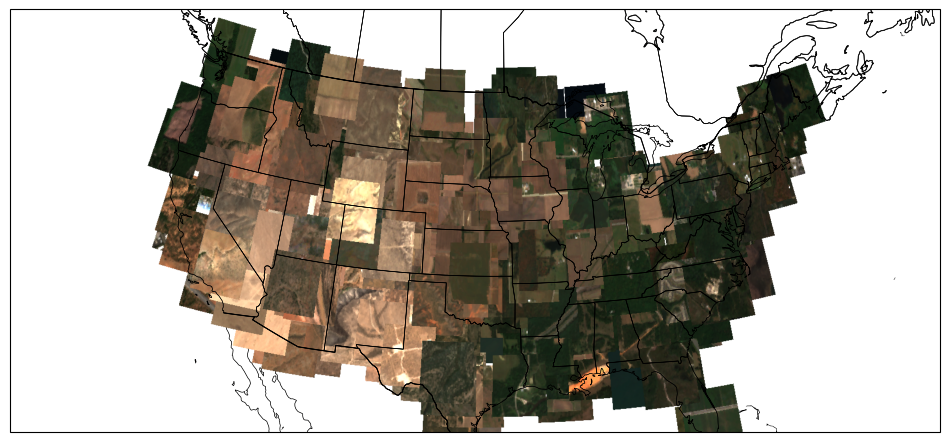

✔ Saved map to output/400_64_10_2024/400_64_10_2024_map.png


In [4]:
# Make a map with the satellite image patches at their lat/lon locations

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ---- USER INPUTS ----
CSV_PATH = f"{OUTPUT_DIR}/{N}_{TILE_PX}_{EMBED_SCALE}_{YEAR}_data.csv"  # your CSV
PATCH_DIR = f"{OUTPUT_DIR}/{N}_{TILE_PX}_{EMBED_SCALE}_{YEAR}_sat_patches"  # folder with patch images
PATCH_SCALE = 4  # fraction of degrees to scale patch size
FIGSIZE = (12, 8)

# ---- LOAD CSV ----
df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df)} points.")

# ---- INIT MAP ----
fig = plt.figure(figsize=FIGSIZE)
ax = plt.axes(projection=ccrs.LambertConformal())
ax.set_extent([-130, -65, 23, 50])  # continental US
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.STATES, linewidth=0.2)
ax.add_feature(cfeature.BORDERS, linewidth=0.8)

# Minimalist land/ocean
ax.add_feature(
    cfeature.LAND, facecolor="white", edgecolor="black"
)  # land white with black borders
ax.add_feature(cfeature.OCEAN, facecolor="white")  # ocean white
ax.add_feature(cfeature.STATES, edgecolor="black", linewidth=0.5)
ax.add_feature(cfeature.BORDERS, edgecolor="black", linewidth=0.5)

# ---- PLOT PATCHES ----
for i, row in df.iterrows():
    lat = row["lat"]
    lon = row["lon"]

    # Compute size in degrees (rough approximation)
    size_deg = PATCH_SCALE  # adjust as needed for zoom

    # Compute bounding box
    lon0, lon1 = lon - size_deg / 2, lon + size_deg / 2
    lat0, lat1 = lat - size_deg / 2, lat + size_deg / 2

    # Load patch image
    patch_path = os.path.join(
        PATCH_DIR, f"patch_{i}_lat{row['lat']:.5f}_lon{row['lon']:.5f}.png"
    )
    if not os.path.exists(patch_path):
        print(f"Patch image not found: {patch_path}")
        continue
    img = mpimg.imread(patch_path)

    # Overlay image on map
    ax.imshow(
        img,
        extent=[lon0, lon1, lat0, lat1],
        transform=ccrs.PlateCarree(),
        origin="upper",
    )

out_path = f"{OUTPUT_DIR}/{N}_{TILE_PX}_{EMBED_SCALE}_{YEAR}_map.png"

plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()  # optional
plt.close()
print(f"✔ Saved map to {out_path}")